In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2010, 2011, 2018, 2019, 2020, 


In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2022, 


In [6]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv'

In [7]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-01-01,θεσσαλιας,αγιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.177143,14.644286,7.71,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,0.018327,0.018327,0.018327,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,0,0
1,22.69237,39.13639,2010-01-01,θεσσαλιας,αλμυρου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.237778,17.085556,11.39,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,0.210382,0.210382,0.210382,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,0,0
2,24.07379,39.32896,2010-01-01,θεσσαλιας,αλοννησου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.090000,17.810000,12.37,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,0.000000,0.000000,0.000000,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,0,0
3,21.43051,39.22138,2010-01-01,θεσσαλιας,αργιθεας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,49.209201,49.209201,49.209201,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,0,0
4,22.88380,39.35198,2010-01-01,θεσσαλιας,βολου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.383333,NaN,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,0.000000,0.000000,0.000000,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,0,0


In [8]:
#Check months

dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-06-01,θεσσαλιας,αγιας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,661.8,10705.00,17.3,45.76610,0.604547,0.239662,-0.369814,-0.239662,0.607976,0.259280,-0.354210,-0.259280,0.037878,0.038561,0.021209,0.038561,18.111429,24.678571,11.544286,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,19.315137,96.170273,594.289658,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,16,0
1,22.69237,39.13639,2010-06-01,θεσσαλιας,αλμυρου,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,905.4,16004.00,20.6,45.23937,0.444394,0.139280,-0.304558,-0.139280,0.408037,0.132123,-0.267725,-0.132123,0.047592,0.051700,0.056671,0.051700,21.662222,28.567778,14.756667,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,16.832220,78.747570,576.739466,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,2,0
2,24.07379,39.32896,2010-06-01,θεσσαλιας,αλοννησου,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,129.6,3153.00,21.2,46.11198,0.478159,0.116885,-0.324981,-0.116885,0.478648,0.107064,-0.344755,-0.107064,0.036931,0.045692,0.017288,0.045692,21.450000,22.830000,20.070000,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,107.927678,187.621050,723.397947,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2010-06-01,θεσσαλιας,αργιθεας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,372.9,3515.00,9.3,44.69433,0.477639,0.247121,-0.159987,-0.247121,0.477005,0.247106,-0.161011,-0.247106,0.040277,0.029637,0.029210,0.029637,16.403333,22.970000,9.836667,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,0.944009,9.219252,670.601435,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,20,0
4,22.88380,39.35198,2010-06-01,θεσσαλιας,βολου,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,385.6,138865.00,374.6,45.52194,0.425591,0.131988,-0.297548,-0.131988,0.325313,0.161796,-0.119200,-0.161796,0.020897,0.011268,0.012894,0.011268,21.530000,28.043333,15.016667,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,12.881553,80.054671,557.697795,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3031,22.55316,39.85211,2021-10-16,θεσσαλιας,τεμπων,16,10,41,2021,-0.101168,-0.994869,-8.660254e-01,0.5,-0.989040,0.147647,576.7,11.99,23.8,45.79122,0.496181,0.108527,-0.447561,-0.108527,0.494762,0.101525,-0.448295,-0.101525,0.062635,0.074820,0.037224,0.074820,21.208000,26.462000,15.954000,5.517741,0.477349,10.868515,4.723090,12.528034,2.774820,19.173602,5.501974,182.178094,252.813196,1038.541043,15826.600671,

In [10]:
dataset2 = read_data(path2, exclude_years = years_to_remove)
dataset2.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2022-01-01,θεσσαλιας,αγιας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.011429,12.470000,7.552857,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,0.000000,0.000000,0.000000,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,31,90,30,90.0,30,90,10,10,1,6,6,2,0,6,0,0
1,22.69237,39.13639,2022-01-01,θεσσαλιας,αλμυρου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.749306,12.377500,7.121111,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,0.000138,0.000138,0.000138,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,11,80,10,72.0,10,72,1,1,7,1,1,2,0,5,0,0
2,24.07379,39.32896,2022-01-01,θεσσαλιας,αλοννησου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.810000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,0.453699,0.453699,0.453699,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,94,20,94.0,20,94,8,8,4,1,1,2,0,1,0,0
3,21.43051,39.22138,2022-01-01,θεσσαλιας,αργιθεας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.273333,10.310000,6.236667,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,0.455287,0.455287,0.455287,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,97,10,99.0,10,99,1,1,7,1,1,2,0,12,0,0
4,22.88380,39.35198,2022-01-01,θεσσαλιας,βολου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.363333,7.776667,8.950000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,0.000000,0.000000,0.000000,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,91,30,91.0,30,91,10,10,1,6,6,2,0,45,0,0


In [11]:
#Check months

dataset2 = dataset2.query('month >= 6 & month <= 10')
dataset2.reset_index(inplace=True, drop=True)

In [12]:
dataset2

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2022-06-01,θεσσαλιας,αγιας,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,661.8,10705.00,17.3,45.76610,0.580607,0.211119,-0.516358,-0.211119,0.588174,0.234598,-0.514727,-0.234598,0.042568,0.042826,0.031391,0.042826,21.688571,25.938571,17.438571,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,17.561027,21.666526,582.394965,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,31,90,30,90.0,30,90,10,10,1,6,6,2,0,6,12,0
1,22.69237,39.13639,2022-06-01,θεσσαλιας,αλμυρου,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,905.4,16004.00,20.6,45.23937,0.510284,0.199673,-0.456633,-0.199673,0.474035,0.182212,-0.424541,-0.182212,0.070062,0.056488,0.042939,0.056488,23.925556,29.343333,18.507778,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,1.861407,10.968027,488.080803,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,11,80,10,72.0,10,72,1,1,7,1,1,2,0,5,10,0
2,24.07379,39.32896,2022-06-01,θεσσαλιας,αλοννησου,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,129.6,3153.00,21.2,46.11198,0.441032,0.098829,-0.402691,-0.098829,0.444082,0.094963,-0.396687,-0.094963,0.031897,0.044945,0.019862,0.044945,23.530000,26.750000,20.310000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,0.609554,1.217267,683.109326,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,94,20,94.0,20,94,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2022-06-01,θεσσαλιας,αργιθεας,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,372.9,3515.00,9.3,44.69433,0.573716,0.302688,-0.469711,-0.302688,0.521032,0.253118,-0.432610,-0.253118,0.049800,0.054291,0.031962,0.054291,21.570000,26.616667,16.523333,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,14.793834,14.972832,375.087157,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,97,10,99.0,10,99,1,1,7,1,1,2,0,12,24,0
4,22.88380,39.35198,2022-06-01,θεσσαλιας,βολου,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,385.6,138865.00,374.6,45.52194,0.479052,0.131846,-0.433818,-0.131846,0.460653,0.121986,-0.418237,-0.121986,0.039999,0.040241,0.027617,0.040241,24.896667,30.783333,19.010000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,8.740168,14.631936,519.033333,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,91,30,91.0,30,91,10,10,1,6,6,2,0,45,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,22.25731,39.56682,2022-09-01,θεσσαλιας,λαρισαιων,1,9,35,2022,0.201299,0.979530,-1.000000e+00,-1.836970e-16,-0.845596,-0.533823,336.0,164381.00,483.9,45.39737,0.242602,-0.186117,-0.266601,0.186117,0.276567,-0.138791,-0.288544,0.138791,0.049921,0.061071,0.036903,0.061071,27.985000,35.770000,20.200000,10.551929,-1.222353,15.475000,0.971818,17.306667,0.820833,28.2993

In [13]:
dataset['lau1'].unique().shape

(25,)

In [14]:
dataset2['lau1'].unique().shape

(25,)

In [15]:
dataset = pd.concat([dataset, dataset2], axis=0)

In [16]:
dataset.reset_index(drop=True, inplace=True)

In [17]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-06-01,θεσσαλιας,αγιας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,661.8,10705.00,17.3,45.76610,0.604547,0.239662,-0.369814,-0.239662,0.607976,0.259280,-0.354210,-0.259280,0.037878,0.038561,0.021209,0.038561,18.111429,24.678571,11.544286,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,19.315137,96.170273,594.289658,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,16,0
1,22.69237,39.13639,2010-06-01,θεσσαλιας,αλμυρου,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,905.4,16004.00,20.6,45.23937,0.444394,0.139280,-0.304558,-0.139280,0.408037,0.132123,-0.267725,-0.132123,0.047592,0.051700,0.056671,0.051700,21.662222,28.567778,14.756667,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,16.832220,78.747570,576.739466,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,2,0
2,24.07379,39.32896,2010-06-01,θεσσαλιας,αλοννησου,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,129.6,3153.00,21.2,46.11198,0.478159,0.116885,-0.324981,-0.116885,0.478648,0.107064,-0.344755,-0.107064,0.036931,0.045692,0.017288,0.045692,21.450000,22.830000,20.070000,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,107.927678,187.621050,723.397947,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2010-06-01,θεσσαλιας,αργιθεας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,372.9,3515.00,9.3,44.69433,0.477639,0.247121,-0.159987,-0.247121,0.477005,0.247106,-0.161011,-0.247106,0.040277,0.029637,0.029210,0.029637,16.403333,22.970000,9.836667,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,0.944009,9.219252,670.601435,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,20,0
4,22.88380,39.35198,2010-06-01,θεσσαλιας,βολου,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.000000e+00,0.508531,-0.861044,385.6,138865.00,374.6,45.52194,0.425591,0.131988,-0.297548,-0.131988,0.325313,0.161796,-0.119200,-0.161796,0.020897,0.011268,0.012894,0.011268,21.530000,28.043333,15.016667,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,12.881553,80.054671,557.697795,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3288,22.25731,39.56682,2022-09-01,θεσσαλιας,λαρισαιων,1,9,35,2022,0.201299,0.979530,-1.000000e+00,-1.836970e-16,-0.845596,-0.533823,336.0,164381.00,483.9,45.39737,0.242602,-0.186117,-0.266601,0.186117,0.276567,-0.138791,-0.288544,0.138791,0.049921,0.061071,0.036903,0.061071,27.985000,35.770000,20.200000,10.551929,-1.222353,15.475000,0.971818,17.306667,0.820833,28.2

In [18]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,244,9,253,7.68%
1,2011,227,30,257,7.80%
2,2012,250,0,250,7.59%
3,2013,250,0,250,7.59%
4,2014,250,0,250,7.59%
5,2015,250,0,250,7.59%
6,2016,250,0,250,7.59%
7,2017,250,0,250,7.59%
8,2018,245,7,252,7.65%
9,2019,220,53,273,8.29%


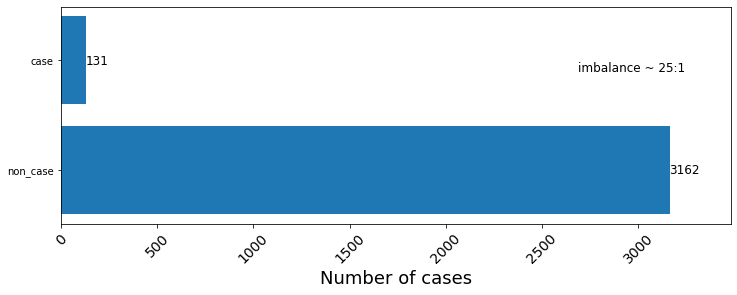

In [19]:
plot_imbalance(dataset)

In [20]:
path3 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-June-1st.csv'
data_test = read_data(path3, exclude_years = years_to_remove)
data_test.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2023-06-01,θεσσαλιας,αγιας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,661.8,10705.0,17.3,45.76610,0.584635,0.243870,-0.491514,-0.243870,0.602969,0.266462,-0.507850,-0.266462,0.054001,0.047529,0.041813,0.047529,17.404286,22.558571,12.250000,10.014591,3.062158,9.497627,2.252233,16.518764,4.850248,17.420808,6.992874,0.241497,39.501188,152.089145,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,31,90,30,90.0,30,90,10,10,1,6,6,2,0,28,0,0
1,22.69237,39.13639,2023-06-01,θεσσαλιας,αλμυρου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,905.4,16004.0,20.6,45.23937,0.498782,0.311438,-0.380998,-0.311438,0.379419,0.283575,-0.272088,-0.283575,0.050555,0.049219,0.048797,0.049219,20.538889,28.616667,12.461111,11.574271,4.271414,11.566611,3.165456,16.910796,6.859971,19.659042,8.292132,1.498979,13.696989,245.229695,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,11,80,10,72.0,10,72,1,1,7,1,1,2,0,15,0,0
2,24.07379,39.32896,2023-06-01,θεσσαλιας,αλοννησου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,129.6,3153.0,21.2,46.11198,0.407767,0.047436,-0.370942,-0.047436,0.409436,0.039487,-0.362686,-0.039487,0.039919,0.040990,0.028623,0.040990,17.930000,23.470000,12.390000,12.912222,9.263333,11.806000,8.335714,15.332667,9.731333,17.710000,11.163333,0.000000,0.003498,203.070749,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,94,20,94.0,20,94,8,8,4,1,1,2,0,2,0,0
3,21.43051,39.22138,2023-06-01,θεσσαλιας,αργιθεας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,372.9,3515.0,9.3,44.69433,0.372873,0.219052,-0.319555,-0.219052,0.434231,0.274862,-0.328888,-0.274862,0.056429,0.045496,0.050196,0.045496,14.683333,19.616667,9.750000,6.545931,2.202813,6.295806,-1.524472,12.140821,3.852222,13.211548,4.210667,0.362346,4.828030,182.232129,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,97,10,99.0,10,99,1,1,7,1,1,2,0,14,0,0
4,22.88380,39.35198,2023-06-01,θεσσαλιας,βολου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,385.6,138865.0,374.6,45.52194,0.389111,0.168842,-0.307572,-0.168842,0.386573,0.155700,-0.316044,-0.155700,0.043922,0.049654,0.041104,0.049654,20.540000,28.870000,12.210000,13.062496,4.339126,13.258730,3.548556,18.642628,6.426410,21.021667,8.192857,1.490073,2.370504,175.827386,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,91,30,91.0,30,91,10,10,1,6,6,2,0,60,0,0


In [21]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [22]:
data_train = dataset
data_test = data_test
    
data_train.reset_index(inplace = True, drop = True)
data_test.reset_index(inplace = True, drop = True)
    
X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_train = data_train['case']
X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_test = data_test['case']
    
X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
w0,w1 = calculate_weights(y_train)

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
results_train = results_train.append(train, ignore_index = True)
results_test = results_test.append(test, ignore_index = True)
coefficients.append(coef)
    
print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2023 || w0:1, w1:10 || ##


In [23]:
results_test.drop(columns='case').head(40)

,x,y,municipality,day,month,year,probability
0,22.55316,39.85211,τεμπων,1,6,2023,0.279542
1,22.25731,39.56682,λαρισαιων,1,6,2023,0.258393
2,22.08404,39.25179,σοφαδων,1,6,2023,0.096116
3,21.72537,39.29671,λιμνης πλαστηρα,1,6,2023,0.069059
4,21.88992,39.23076,καρδιτσας,1,6,2023,0.059177
5,21.95164,39.48269,παλαμα,1,6,2023,0.054745
6,22.34300,39.82847,τυρναβου,1,6,2023,0.026932
7,22.02056,39.60375,φαρκαδονας,1,6,2023,0.023006
8,22.47968,39.49921,κιλελερ,1,6,2023,0.022255
9,22.16727,39.98970,ελασσονας,1,6,2023,0.021020
